In [ ]:
import numpy as np
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForQuestionAnswering,   #Bert
    AutoModelForSeq2SeqLM,       #BART,T5
    Seq2SeqTrainer,              #Train models Bart ,T5
    EarlyStoppingCallback,
    Seq2SeqTrainingArguments,   
)

import torch


In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
print(torch.cuda.get_device_name(0))

Using device: cuda
Quadro T2000


In [3]:
# QA (BERT)
qa_tokenizer = AutoTokenizer.from_pretrained("deepset/bert-base-uncased-squad2")
qa_model     = AutoModelForQuestionAnswering.from_pretrained("deepset/bert-base-uncased-squad2")

# Summarization (DistilBART)
sum_tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
sum_model     = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

# Quiz Generation (T5)
# FIX: valhalla/t5-base-qg-hl (Question Generation)
quiz_tokenizer = AutoTokenizer.from_pretrained("valhalla/t5-base-qg-hl")
quiz_model     = AutoModelForSeq2SeqLM.from_pretrained("valhalla/t5-base-qg-hl")

# Move to GPU
qa_model   = qa_model.to(device)
sum_model  = sum_model.to(device)
quiz_model = quiz_model.to(device)

print("All models loaded!")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/358 [00:00<?, ?it/s]

pytorch_model.bin:   0%|          | 0.00/892M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

All models loaded!


In [4]:
# QA & Quiz Generation
squad = load_dataset("squad", split="train")

# Summarization
cnn = load_dataset("cnn_dailymail", "3.0.0", split="train[:20000]")

print("SQuAD loaded       →", len(squad), "samples")
print("CNN/DailyMail loaded →", len(cnn),   "samples")

SQuAD loaded       → 87599 samples
CNN/DailyMail loaded → 20000 samples


In [5]:
print("── SQuAD Sample ──")
print("Context :", squad[0]['context'][:300])
print("Question:", squad[0]['question'])
print("Answer  :", squad[0]['answers'])

print("\n── CNN/DailyMail Sample ──")
print("Article :", cnn[0]['article'][:300])
print("Summary :", cnn[0]['highlights'][:200])

── SQuAD Sample ──
Context : Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing it, is a copper statue of Christ with arms upraised with the legend "Venite Ad Me Omnes". Next to the Main Building is 
Question: To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France?
Answer  : {'text': ['Saint Bernadette Soubirous'], 'answer_start': [515]}

── CNN/DailyMail Sample ──
Article : LONDON, England (Reuters) -- Harry Potter star Daniel Radcliffe gains access to a reported £20 million ($41.1 million) fortune as he turns 18 on Monday, but he insists the money won't cast a spell on him. Daniel Radcliffe as Harry Potter in "Harry Potter and the Order of the Phoenix" To the disappoi
Summary : Harry Potter star Daniel Radcliffe gets £20M fortune as he turns 18 Monday .
Young actor says he has no plans to fritter his cash away .
Radcliffe's earnings from fi

# EDA

In [ ]:
#Convert Data"json""  to dataframe
squad_df = pd.DataFrame({
    'question' : [x['question']           for x in squad],
    'context'  : [x['context']            for x in squad],
    'answer'   : [x['answers']['text'][0] for x in squad],
})

cnn_df = pd.DataFrame({
    'article' : cnn['article'],
    'summary' : cnn['highlights'],
})

print("SQuAD shape :", squad_df.shape)
print("CNN shape   :", cnn_df.shape)

SQuAD shape : (87599, 3)
CNN shape   : (20000, 2)


In [7]:
squad_df.head()

,question,context,answer
0,To whom did the Virgin Mary allegedly appear i...,"Architecturally, the school has a Catholic cha...",Saint Bernadette Soubirous
1,What is in front of the Notre Dame Main Building?,"Architecturally, the school has a Catholic cha...",a copper statue of Christ
2,The Basilica of the Sacred heart at Notre Dame...,"Architecturally, the school has a Catholic cha...",the Main Building
3,What is the Grotto at Notre Dame?,"Architecturally, the school has a Catholic cha...",a Marian place of prayer and reflection
4,What sits on top of the Main Building at Notre...,"Architecturally, the school has a Catholic cha...",a golden statue of the Virgin Mary


In [8]:
cnn_df.head()

,article,summary
0,"LONDON, England (Reuters) -- Harry Potter star...",Harry Potter star Daniel Radcliffe gets £20M f...
1,Editor's note: In our Behind the Scenes series...,Mentally ill inmates in Miami are housed on th...
2,"MINNEAPOLIS, Minnesota (CNN) -- Drivers who we...","NEW: ""I thought I was going to die,"" driver sa..."
3,WASHINGTON (CNN) -- Doctors removed five small...,"Five small polyps found during procedure; ""non..."
4,(CNN) -- The National Football League has ind...,"NEW: NFL chief, Atlanta Falcons owner critical..."


In [9]:
token_fun = lambda x: len(x.split())

squad_df['question_len'] = squad_df['question'].apply(token_fun)
squad_df['context_len']  = squad_df['context'].apply(token_fun)
squad_df['answer_len']   = squad_df['answer'].apply(token_fun)

cnn_df['article_len'] = cnn_df['article'].apply(token_fun)
cnn_df['summary_len'] = cnn_df['summary'].apply(token_fun)

print("── SQuAD ──")
print(squad_df[['question_len','context_len','answer_len']].describe().round(1))

print("\n── CNN/DailyMail ──")
print(cnn_df[['article_len','summary_len']].describe().round(1))

── SQuAD ──
       question_len  context_len  answer_len
count       87599.0      87599.0     87599.0
mean           10.1        119.8         3.2
std             3.6         49.4         3.4
min             1.0         20.0         1.0
25%             8.0         89.0         1.0
50%            10.0        110.0         2.0
75%            12.0        142.0         3.0
max            40.0        653.0        43.0

── CNN/DailyMail ──
       article_len  summary_len
count      20000.0      20000.0
mean         596.8         44.4
std          319.1          9.0
min           18.0         11.0
25%          348.0         38.0
50%          533.0         45.0
75%          792.0         51.0
max         1831.0         90.0


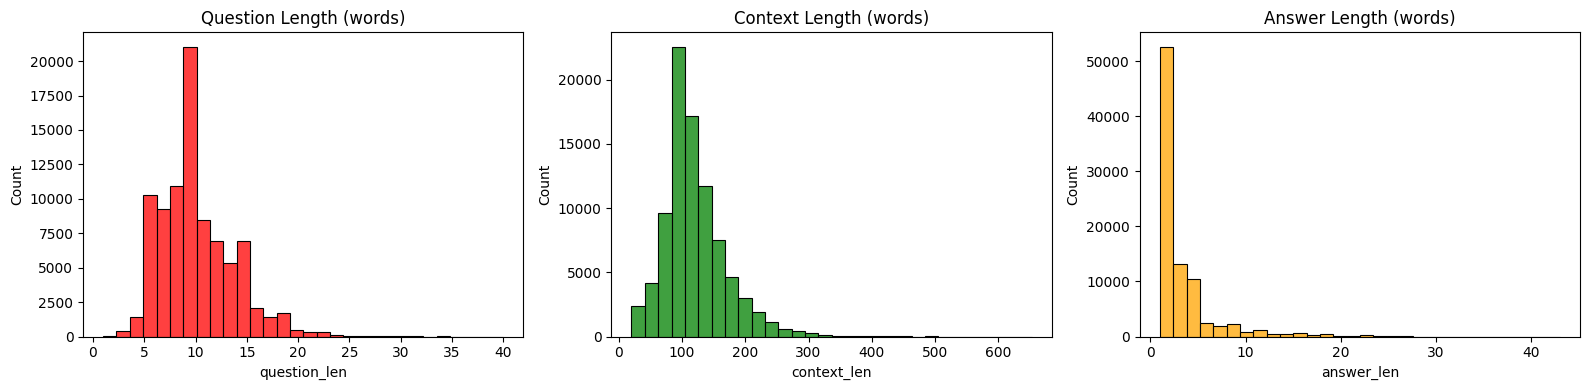

In [ ]:
# بيشوف كل جمله فيها كام كلمة ... ويشوف تكرار الجمل المتشابهة ف العدد
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(squad_df['question_len'], bins=30, ax=axes[0], color='red')
axes[0].set_title('Question Length (words)')

sns.histplot(squad_df['context_len'], bins=30, ax=axes[1], color='green')
axes[1].set_title('Context Length (words)')

sns.histplot(squad_df['answer_len'], bins=30, ax=axes[2], color='orange')
axes[2].set_title('Answer Length (words)')

plt.tight_layout()
plt.show()

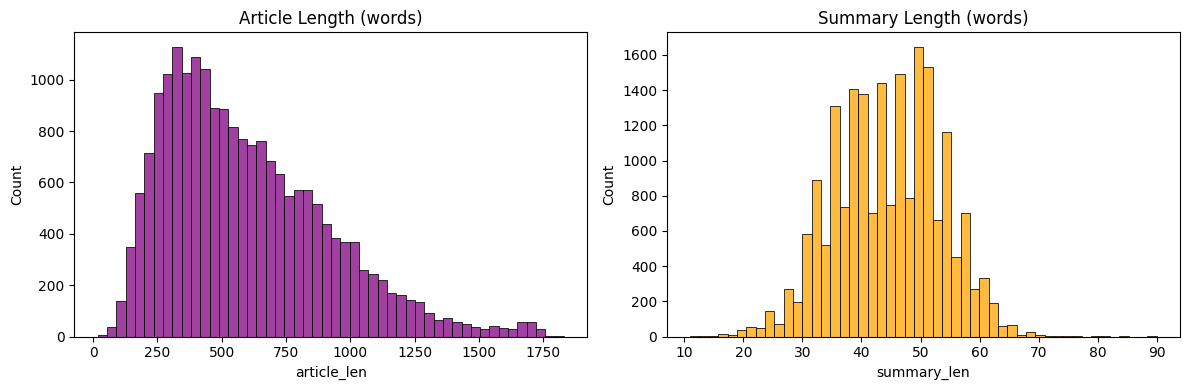

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(cnn_df['article_len'], bins=50, ax=axes[0], color='purple')
axes[0].set_title('Article Length (words)')

sns.histplot(cnn_df['summary_len'], bins=50, ax=axes[1], color='orange')
axes[1].set_title('Summary Length (words)')

plt.tight_layout()
plt.show()

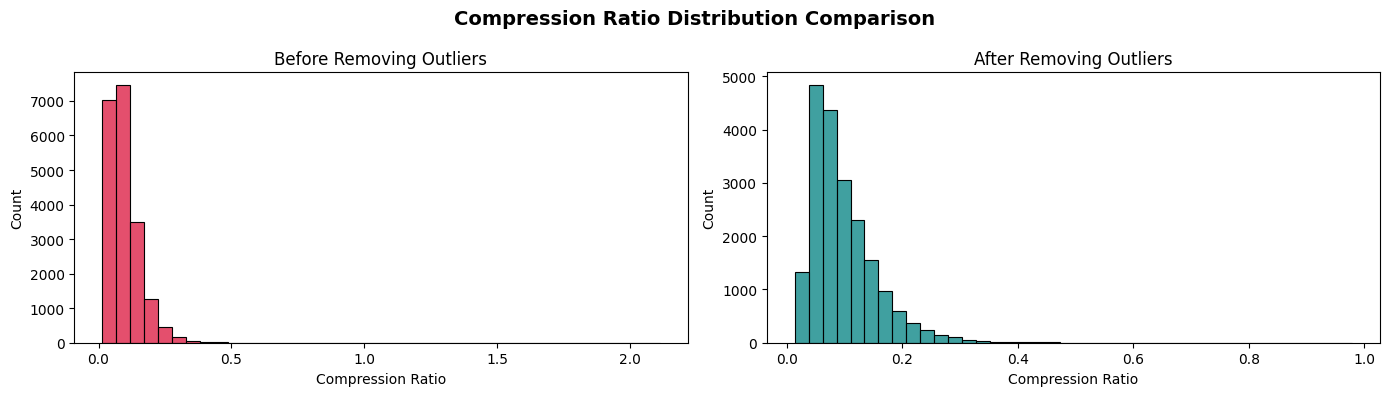

In [ ]:
#probablity Lenght of summery and Article 
#  1>CR>0  is good summery is less than article , if cr>1 is not good Because the summery is greater than the article 
cnn_df['compression_ratio'] = cnn_df['summary_len'] / cnn_df['article_len']

filtered_df = cnn_df[cnn_df['compression_ratio'] < 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(cnn_df['compression_ratio'], bins=40, color='crimson', ax=axes[0])
axes[0].set_title('Before Removing Outliers')
axes[0].set_xlabel('Compression Ratio')

sns.histplot(filtered_df['compression_ratio'], bins=40, color='teal', ax=axes[1])
axes[1].set_title('After Removing Outliers')
axes[1].set_xlabel('Compression Ratio')

plt.suptitle('Compression Ratio Distribution Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

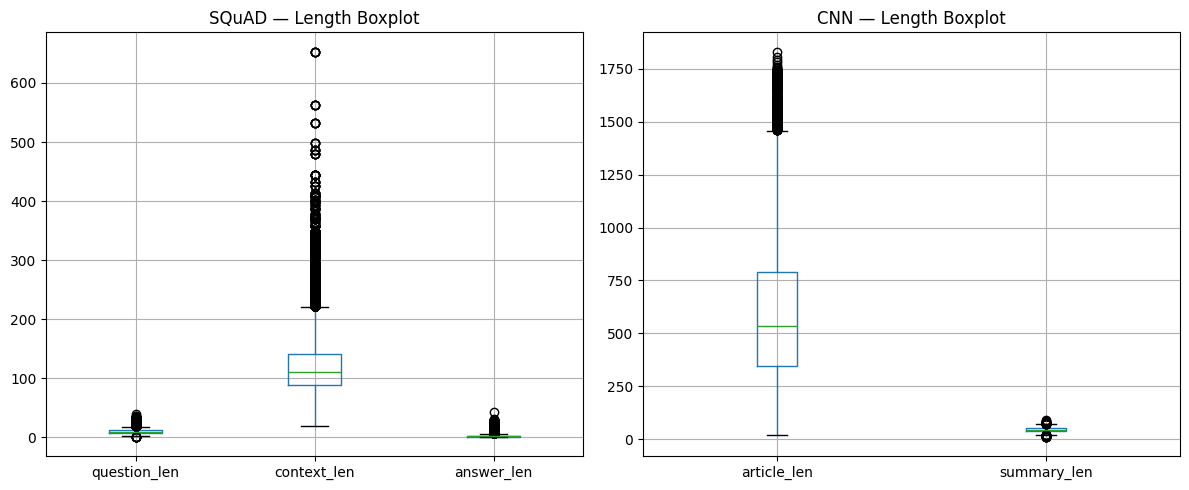

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

squad_df[['question_len','context_len','answer_len']].boxplot(ax=axes[0])
axes[0].set_title('SQuAD — Length Boxplot')

cnn_df[['article_len','summary_len']].boxplot(ax=axes[1])
axes[1].set_title('CNN — Length Boxplot')

plt.tight_layout()
plt.show()

C:\Users\abuma\AppData\Local\Temp\ipykernel_3732\2336448443.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='Set2')


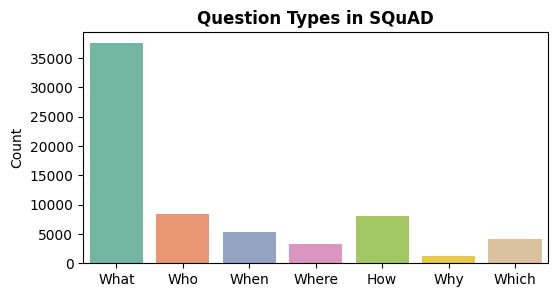

In [14]:
question_words = ['What', 'Who', 'When', 'Where', 'How', 'Why', 'Which']

counts = {
    w: squad_df['question'].str.startswith(w).sum()
    for w in question_words
}

plt.figure(figsize=(6, 3))
sns.barplot(x=list(counts.keys()), y=list(counts.values()), palette='Set2')
plt.title('Question Types in SQuAD', fontweight='bold')
plt.ylabel('Count')
plt.show()

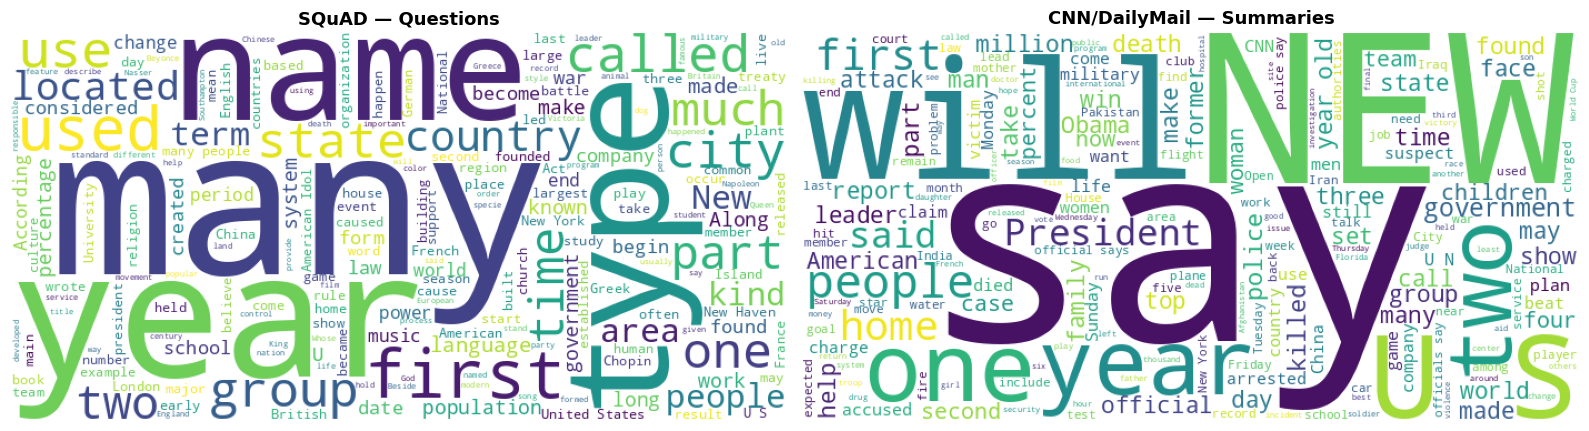

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc1 = WordCloud(width=700, height=350, background_color='white').generate(
    ' '.join(squad_df['question'])
)
axes[0].imshow(wc1)
axes[0].axis('off')
axes[0].set_title('SQuAD — Questions', fontsize=13, fontweight='bold')

wc2 = WordCloud(width=700, height=350, background_color='white').generate(
    ' '.join(cnn_df['summary'].sample(5000, random_state=42))
)
axes[1].imshow(wc2)
axes[1].axis('off')
axes[1].set_title('CNN/DailyMail — Summaries', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Preprocessing

In [ ]:
def clean_text(text):
    text = text.strip()    #remove spaces from start & end strings
    text = re.sub(r'\s+', ' ', text)   # any grater 1 space replace it with only one space
    return text

squad_df['question'] = squad_df['question'].apply(clean_text)
squad_df['context']  = squad_df['context'].apply(clean_text)
squad_df['answer']   = squad_df['answer'].apply(clean_text)

cnn_df['article'] = cnn_df['article'].apply(clean_text)
cnn_df['summary'] = cnn_df['summary'].apply(clean_text)

print("Cleaning done!")

Cleaning done!


In [17]:
print("── SQuAD ──")
print(squad_df.isnull().sum())

print("\n── CNN ──")
print(cnn_df.isnull().sum())

── SQuAD ──
question        0
context         0
answer          0
question_len    0
context_len     0
answer_len      0
dtype: int64

── CNN ──
article              0
summary              0
article_len          0
summary_len          0
compression_ratio    0
dtype: int64


In [18]:
squad_df = squad_df.dropna().reset_index(drop=True)
cnn_df   = cnn_df.dropna().reset_index(drop=True)

print("SQuAD :", len(squad_df), "samples")
print("CNN   :", len(cnn_df),   "samples")

SQuAD : 87599 samples
CNN   : 20000 samples


In [19]:
def get_iqr_bounds(df, col):
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return lower, upper

In [20]:
print("── SQuAD ──")
for col in ['question_len', 'context_len', 'answer_len']:
    lower, upper = get_iqr_bounds(squad_df, col)
    outliers = squad_df[(squad_df[col] < lower) | (squad_df[col] > upper)]
    print(f"{col} → Lower: {lower:.1f} | Upper: {upper:.1f} | Outliers: {len(outliers)}")

print("\n── CNN ──")
for col in ['article_len', 'summary_len']:
    lower, upper = get_iqr_bounds(cnn_df, col)
    outliers = cnn_df[(cnn_df[col] < lower) | (cnn_df[col] > upper)]
    print(f"{col} → Lower: {lower:.1f} | Upper: {upper:.1f} | Outliers: {len(outliers)}")

── SQuAD ──
question_len → Lower: 2.0 | Upper: 18.0 | Outliers: 2109
context_len → Lower: 9.5 | Upper: 221.5 | Outliers: 3533
answer_len → Lower: -2.0 | Upper: 6.0 | Outliers: 8935

── CNN ──
article_len → Lower: -318.0 | Upper: 1458.0 | Outliers: 338
summary_len → Lower: 18.5 | Upper: 70.5 | Outliers: 58


In [21]:
for col in ['question_len', 'context_len', 'answer_len']:
    lower, upper = get_iqr_bounds(squad_df, col)
    squad_df = squad_df[(squad_df[col] >= lower) & (squad_df[col] <= upper)]
squad_df = squad_df.reset_index(drop=True)

for col in ['article_len', 'summary_len']:
    lower, upper = get_iqr_bounds(cnn_df, col)
    cnn_df = cnn_df[(cnn_df[col] >= lower) & (cnn_df[col] <= upper)]
cnn_df = cnn_df.reset_index(drop=True)

print("After removing outliers:")
print("SQuAD :", len(squad_df), "samples")
print("CNN   :", len(cnn_df),   "samples")

After removing outliers:
SQuAD : 76731 samples
CNN   : 19604 samples


In [ ]:
#Formatting the data for the Transformer train
def make_qg_input(row):   #Promt input formating >>> from Context + Answer == Generate Quiz
    context = row['context']
    answer  = row['answer']
    idx = context.lower().find(answer.lower())   #search answer in context
    if idx == -1:
        return "generate question: " + context     #If answer not found return only context
    before = context[:idx]
    match  = context[idx : idx + len(answer)]
    after  = context[idx + len(answer):]
    return f"generate question: {before}<hl> {match} <hl>{after}"

squad_df['quiz_input'] = squad_df.apply(make_qg_input, axis=1)
squad_df['qa_input']   = squad_df['question'] + " [SEP] " + squad_df['context']

print("── QA Input ──")
print(squad_df['qa_input'][0][:200])
print("\n── Quiz Input (Highlighted) ──")
print(squad_df['quiz_input'][0][:200])


── QA Input ──
To whom did the Virgin Mary allegedly appear in 1858 in Lourdes France? [SEP] Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin 

── Quiz Input (Highlighted) ──
generate question: Architecturally, the school has a Catholic character. Atop the Main Building's gold dome is a golden statue of the Virgin Mary. Immediately in front of the Main Building and facing 


In [23]:
from sklearn.model_selection import train_test_split

squad_train, squad_test = train_test_split(squad_df, test_size=0.2, random_state=42)
cnn_train,   cnn_test   = train_test_split(cnn_df,   test_size=0.2, random_state=42)

squad_train = squad_train.sample(13000, random_state=42)
squad_test  = squad_test.sample(3000, random_state=42)

cnn_train = cnn_train.sample(8000, random_state=42)
cnn_test  = cnn_test.sample(1800, random_state=42)

print("SQuAD → Train:", len(squad_train), "| Test:", len(squad_test))
print("CNN   → Train:", len(cnn_train),   "| Test:", len(cnn_test))

SQuAD → Train: 13000 | Test: 3000
CNN   → Train: 8000 | Test: 1800


# Modeling & Training

In [ ]:
#Custom DataSet

from torch.utils.data import Dataset

class QADataset(Dataset):

    def __init__(self, df, tokenizer):
        self.df = df.reset_index(drop=True)

        self.encodings = tokenizer(
            self.df['question'].tolist(),
            self.df['context'].tolist(),
            truncation='only_second',    
            max_length=384,            
            padding=True,
            return_offsets_mapping=True,    # ids
            return_tensors='pt'
        )

        self.start_positions = []
        self.end_positions   = []
        self.valid_mask      = []       
        for idx in range(len(self.df)):
            answer  = self.df['answer'].iloc[idx]
            context = self.df['context'].iloc[idx]

            start_char = context.find(answer)

            if start_char == -1:
                self.start_positions.append(0)
                self.end_positions.append(0)
                self.valid_mask.append(False)
                continue

            self.valid_mask.append(True)
            end_char = start_char + len(answer)

            seq_ids        = self.encodings.sequence_ids(idx)
            offset_mapping = self.encodings['offset_mapping'][idx]

            start_pos, end_pos = 0, 0

            for i, (seq_id, (s, e)) in enumerate(zip(seq_ids, offset_mapping)):
                if seq_id != 1:
                    continue
                s, e = int(s), int(e)
                if s <= start_char < e:
                    start_pos = i
                if s < end_char <= e:
                    end_pos = i
                    break

            self.start_positions.append(start_pos)
            self.end_positions.append(end_pos)

        valid_indices = [i for i, v in enumerate(self.valid_mask) if v]
        if len(valid_indices) < len(self.df):
            skipped = len(self.df) - len(valid_indices)
            print(f" Skipped {skipped} samples (answer not found in context)")

            self.encodings = {
                'input_ids'      : self.encodings['input_ids'][valid_indices],
                'attention_mask' : self.encodings['attention_mask'][valid_indices],
            }
            self.start_positions = [self.start_positions[i] for i in valid_indices]
            self.end_positions   = [self.end_positions[i]   for i in valid_indices]

    def __len__(self):
        return len(self.start_positions)

    def __getitem__(self, idx):
        return {
            'input_ids'       : self.encodings['input_ids'][idx],
            'attention_mask'  : self.encodings['attention_mask'][idx],
            'start_positions' : torch.tensor(self.start_positions[idx]),
            'end_positions'   : torch.tensor(self.end_positions[idx])
        }


# ── BART & T5 (Seq2Seq) ── Pre-tokenized ──
class Seq2SeqDataset(Dataset):

    def __init__(self, df, tokenizer, input_col, target_col,
                 input_max_len, target_max_len, prefix=""):

        self.df = df.reset_index(drop=True)

        inputs  = [prefix + str(x) for x in self.df[input_col]]
        targets = [str(x)          for x in self.df[target_col]]

        self.src_enc = tokenizer(
            inputs,
            truncation=True,
            max_length=input_max_len,
            padding=True,
            return_tensors='pt'
        )

        tgt_enc = tokenizer(
            targets,
            truncation=True,
            max_length=target_max_len,
            padding=True,
            return_tensors='pt'
        )

        self.labels = tgt_enc['input_ids'].clone()
        self.labels[self.labels == tokenizer.pad_token_id] = -100

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        return {
            'input_ids'     : self.src_enc['input_ids'][idx],
            'attention_mask': self.src_enc['attention_mask'][idx],
            'labels'        : self.labels[idx]
        }

print("Dataset classes ready!")


Dataset classes ready!


In [ ]:
print("Pre-tokenizing QA datasets...")
qa_train_ds = QADataset(squad_train, qa_tokenizer)
qa_test_ds  = QADataset(squad_test,  qa_tokenizer)
print("QA done!")

print("Pre-tokenizing SUM datasets...")
sum_train_ds = Seq2SeqDataset(
    cnn_train, sum_tokenizer,
    'article', 'summary',
    512,  
    128
)
sum_test_ds = Seq2SeqDataset(
    cnn_test, sum_tokenizer,
    'article', 'summary',
    512, 
    128
    
)
print("SUM done!")

print("Pre-tokenizing Quiz datasets...")
quiz_train_ds = Seq2SeqDataset(
    squad_train, quiz_tokenizer,
    'quiz_input',
    'question',
    512,
    64,
    prefix=""
)
quiz_test_ds = Seq2SeqDataset(
    squad_test, quiz_tokenizer,
    'quiz_input',
    'question',
    512,
    64,
    prefix=""
)
print("Quiz done!")

print("\nQA   → Train:", len(qa_train_ds),   "| Test:", len(qa_test_ds))
print("SUM  → Train:", len(sum_train_ds),  "| Test:", len(sum_test_ds))
print("Quiz → Train:", len(quiz_train_ds), "| Test:", len(quiz_test_ds))


Pre-tokenizing QA datasets...
QA done!
Pre-tokenizing SUM datasets...
SUM done!
Pre-tokenizing Quiz datasets...
Quiz done!

QA   → Train: 13000 | Test: 3000
SUM  → Train: 8000 | Test: 1800
Quiz → Train: 13000 | Test: 3000


# Train BERT (QA) 

In [ ]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback

qa_trainer = Trainer(
    model         = qa_model,
    train_dataset = qa_train_ds,
    eval_dataset  = qa_test_ds,
    callbacks     = [EarlyStoppingCallback(early_stopping_patience=2)],
    args          = TrainingArguments(
        output_dir                  = './models_lg/qa_model',
        num_train_epochs            = 5,
        learning_rate               = 3e-5,   # optimizer adam bultin in model
        per_device_train_batch_size = 6,
        per_device_eval_batch_size  = 8,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',   #Check points
        load_best_model_at_end      = True,     #Save Best Model
        fp16                        = True,     #Enhance and optimzation ram & Vram
        warmup_steps                = 100,     # Fist 100 steps is const learning rete
        weight_decay                = 0.01,    # reduce overvitting "Regularization"
        logging_steps               = 50,    # after 50 step print logs 
    )
)

qa_trainer.train()
print("BERT QA Done!")

Epoch,Training Loss,Validation Loss
1,0.616797,0.533632
2,0.446697,0.620871
3,0.146881,1.015252


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

BERT QA Done!


# Train BART (Summarization) 

In [ ]:
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

sum_trainer = Seq2SeqTrainer(
    model         = sum_model,
    train_dataset = sum_train_ds,
    eval_dataset  = sum_test_ds,
    callbacks     = [EarlyStoppingCallback(early_stopping_patience=2)],
    args          = Seq2SeqTrainingArguments(
        output_dir                  = './models_lg/sum_model',
        num_train_epochs            = 3,
        learning_rate               = 3e-5,
        per_device_train_batch_size = 2,
        per_device_eval_batch_size  = 2,
        gradient_accumulation_steps = 2,
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        load_best_model_at_end      = True,
        predict_with_generate       = True,   #When train generat text
        fp16                        = True,
        warmup_steps                = 200,
        weight_decay                = 0.01,
        logging_steps               = 100,
    )
)

sum_trainer.train()
print("BART Summarization Done!")


Epoch,Training Loss,Validation Loss
1,3.582184,1.685627
2,2.662759,1.682351
3,1.871591,1.775747


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


BART Summarization Done!


# Train T5 (Quiz Generation) 
## in second NoteBook

# Save Models

In [38]:
import os

for path in ['./models_lg/qa_model', './models_lg/sum_model', './models_lg/quiz_model']:
    os.makedirs(path, exist_ok=True)

qa_model.save_pretrained('./models_lg/qa_model')
qa_tokenizer.save_pretrained('./models_lg/qa_model')

sum_model.save_pretrained('./models_lg/sum_model')
sum_tokenizer.save_pretrained('./models_lg/sum_model')

quiz_model.save_pretrained('./models_lg/quiz_model')
quiz_tokenizer.save_pretrained('./models_lg/quiz_model')

print("All models saved!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All models saved!


✅ Loading from: checkpoint-6501
✅ Loading from: checkpoint-6000
✅ Loading from: checkpoint-9750


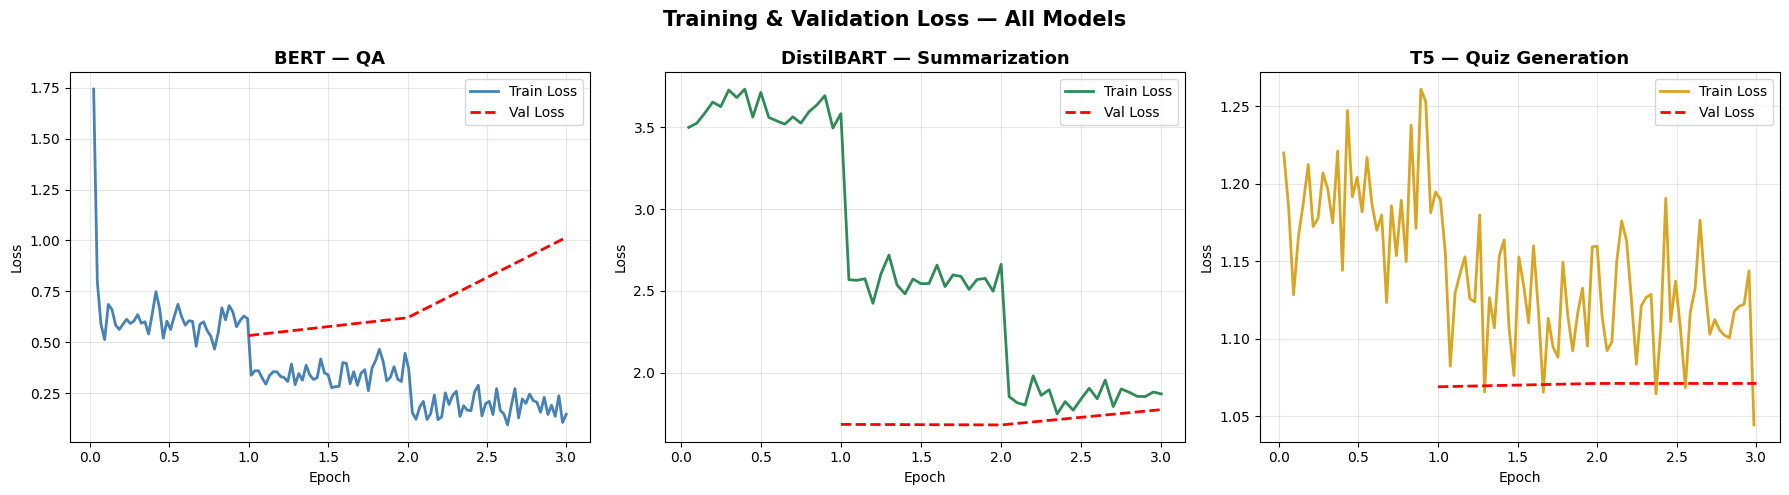

In [ ]:
import json
import os
import matplotlib.pyplot as plt

def load_log_history(model_path):
    
    main_path = f"{model_path}/trainer_state.json"
    if os.path.exists(main_path):
        with open(main_path, "r") as f:
            return json.load(f)["log_history"]
    
    checkpoints = sorted([
        d for d in os.listdir(model_path)
        if d.startswith("checkpoint-")
    ], key=lambda x: int(x.split("-")[1]))
    
    if checkpoints:
        last_checkpoint = checkpoints[-1]  # آخر checkpoint
        ckpt_path = f"{model_path}/{last_checkpoint}/trainer_state.json"
        if os.path.exists(ckpt_path):
            print(f"✅ Loading from: {last_checkpoint}")
            with open(ckpt_path, "r") as f:
                return json.load(f)["log_history"]
    
    print(f"Can`t find trainer_state.json {model_path}")
    return []

def extract_losses(log_history):
    train_loss, eval_loss = [], []
    for x in log_history:
        if 'loss' in x and 'eval_loss' not in x:
            train_loss.append((x['epoch'], x['loss']))
        if 'eval_loss' in x:
            eval_loss.append((x['epoch'], x['eval_loss']))
    return train_loss, eval_loss

# ── تحميل الـ logs ──
qa_logs   = load_log_history('./models_lg/qa_model')
sum_logs  = load_log_history('./models_lg/sum_model')
quiz_logs = load_log_history('./models_lg/quiz_model')

qa_train,   qa_eval   = extract_losses(qa_logs)
sum_train,  sum_eval  = extract_losses(sum_logs)
quiz_train, quiz_eval = extract_losses(quiz_logs)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, train, val, title, color in zip(
    axes,
    [qa_train, sum_train, quiz_train],
    [qa_eval,  sum_eval,  quiz_eval],
    ['BERT — QA', 'DistilBART — Summarization', 'T5 — Quiz Generation'],
    ['steelblue', 'seagreen', 'goldenrod']
):
    if train:
        ax.plot([e for e,l in train], [l for e,l in train],
                label='Train Loss', color=color, linewidth=2)
    if val:
        ax.plot([e for e,l in val], [l for e,l in val],
                label='Val Loss', color='red', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training & Validation Loss — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [40]:
# QA Evaluation (Exact Match + F1)

import evaluate
squad_metric = evaluate.load("squad")

def get_answer(question, context, model, tokenizer, device):
    inputs = tokenizer(
        question, context,
        return_tensors='pt',
        truncation=True,
        max_length=384   
    ).to(device)
    with torch.no_grad():
        outputs = model(**inputs)

    start_logits = outputs.start_logits[0]
    end_logits   = outputs.end_logits[0]
    seq_len      = inputs['input_ids'].shape[1]

    start = torch.argmax(start_logits).item()
    end   = torch.argmax(end_logits).item()

    if end < start:
        end = start + 1
    end = min(end, seq_len - 1)

    answer = tokenizer.decode(
        inputs['input_ids'][0][start:end + 1],
        skip_special_tokens=True
    )
    return answer.strip()

# ── Run on 100 samples ──
sample_qa = squad_test.sample(100, random_state=42)

preds = []
refs  = []

for i, (_, row) in enumerate(sample_qa.iterrows()):
    pred = get_answer(row['question'], row['context'], qa_model, qa_tokenizer, device)
    preds.append({"id": str(i), "prediction_text": pred})
    refs.append({"id": str(i), "answers": {"text": [row['answer']], "answer_start": [0]}})

qa_results = squad_metric.compute(predictions=preds, references=refs)

print("=" * 40)
print("   BERT — Question Answering Results")
print("=" * 40)
print(f"  Exact Match : {qa_results['exact_match']:.2f}%")
print(f"  F1 Score    : {qa_results['f1']:.2f}%")
print("=" * 40)


   BERT — Question Answering Results
  Exact Match : 72.00%
  F1 Score    : 82.95%


In [42]:
# Summarization ROUGE

rouge = evaluate.load("rouge")

def generate_summary(text, model, tokenizer, device, max_len=128):
    inputs = tokenizer(
        text, return_tensors='pt',
        max_length=512,  
        truncation=True
    ).to(device)
    with torch.no_grad():
        outputs = model.generate(
            inputs['input_ids'],
            max_length=max_len,
            num_beams=4,
            early_stopping=True
        )
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# ── Run on 80 samples ──
sample_sum = cnn_test.sample(40, random_state=42)

sum_preds = []
sum_refs  = []

for _, row in sample_sum.iterrows():
    pred = generate_summary(row['article'], sum_model, sum_tokenizer, device)
    sum_preds.append(pred)
    sum_refs.append(row['summary'])

sum_results = rouge.compute(predictions=sum_preds, references=sum_refs)

print("=" * 40)
print("   DistilBART — Summarization Results")
print("=" * 40)
for k, v in sum_results.items():
    print(f"  {k:<12}: {v:.4f}")
print("=" * 40)


   DistilBART — Summarization Results
  rouge1      : 0.3787
  rouge2      : 0.1569
  rougeL      : 0.2663
  rougeLsum   : 0.2673
